<a href="https://colab.research.google.com/github/saichougale/IPCV/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup: Import Libraries
This cell imports all necessary Python libraries required for the entire analysis workflow. `pandas` is used for data manipulation and analysis, `numpy` for numerical operations, `matplotlib.pyplot` for creating static, interactive, and animated visualizations, and `seaborn` for making statistical graphics more attractive and informative.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading: Mount Google Drive
This step connects the Google Colab environment to your Google Drive. This is essential for accessing files, such as the `customer_shopping_data.csv` dataset, that are stored in your Drive, allowing the notebook to read and process them.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Loading: Load Dataset
This cell loads the `customer_shopping_data.csv` file from the specified Google Drive path into a Pandas DataFrame named `df`. A DataFrame is a two-dimensional, size-mutable, and potentially heterogeneous tabular data structure with labeled axes (rows and columns). The `df.head()` command then displays the first 5 rows of the DataFrame, providing a quick preview of the data's structure and content.

In [4]:
df = pd.read_csv('/content/drive/My Drive/ML LAB/TYAssignments/customer_shopping_data.csv')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


### Initial Data Exploration: Check DataFrame Shape
This cell uses `df.shape` to display the dimensions of the DataFrame. The output `(rows, columns)` indicates the total number of entries (rows) and the number of features (columns) in your dataset. This is a crucial first step to understand the scale of the data you are working with.

In [8]:
df.shape

(99457, 10)

### Initial Data Exploration: Descriptive Statistics
Executing `df.describe()` generates descriptive statistics for all numerical columns in the DataFrame. This includes count, mean, standard deviation (std), minimum (min), maximum (max), and the interquartile range (25th, 50th, and 75th percentiles). These statistics help to understand the central tendency, dispersion, and shape of the distribution of numerical features.

In [9]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


### Initial Data Exploration: DataFrame Information
`df.info()` provides a concise summary of the DataFrame. It includes the index dtype and column dtypes, non-null values, and memory usage. This is extremely useful for quickly checking data types, identifying potential issues like columns with many missing values (indicated by non-null counts less than the total entries), and estimating memory consumption.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


### Initial Data Exploration: Check for Missing Values
This cell calculates the total number of missing (null) values for each column in the DataFrame using `df.isnull().sum()`. Identifying missing data is a critical step in data preprocessing, as missing values can affect the accuracy and performance of machine learning models. In this case, the output shows no missing values, which is ideal.

In [12]:
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


### Data Visualization: Import Missingno
This cell imports the `missingno` library, which specializes in visualizing the completeness of a dataset. `missingno` offers various plot types to quickly and clearly identify patterns of missing data, making it easier to decide on appropriate imputation or handling strategies.

In [13]:
import missingno as msno

### Data Visualization: Visualize Missing Data
`msno.matrix(df)` generates a matrix plot that provides a visual representation of missing data across the DataFrame. Each row corresponds to a data entry, and each column to a feature. The presence of a line indicates a non-missing value, while a blank space indicates a missing value. This plot is effective for quickly assessing the density and distribution of missingness.

<Axes: >

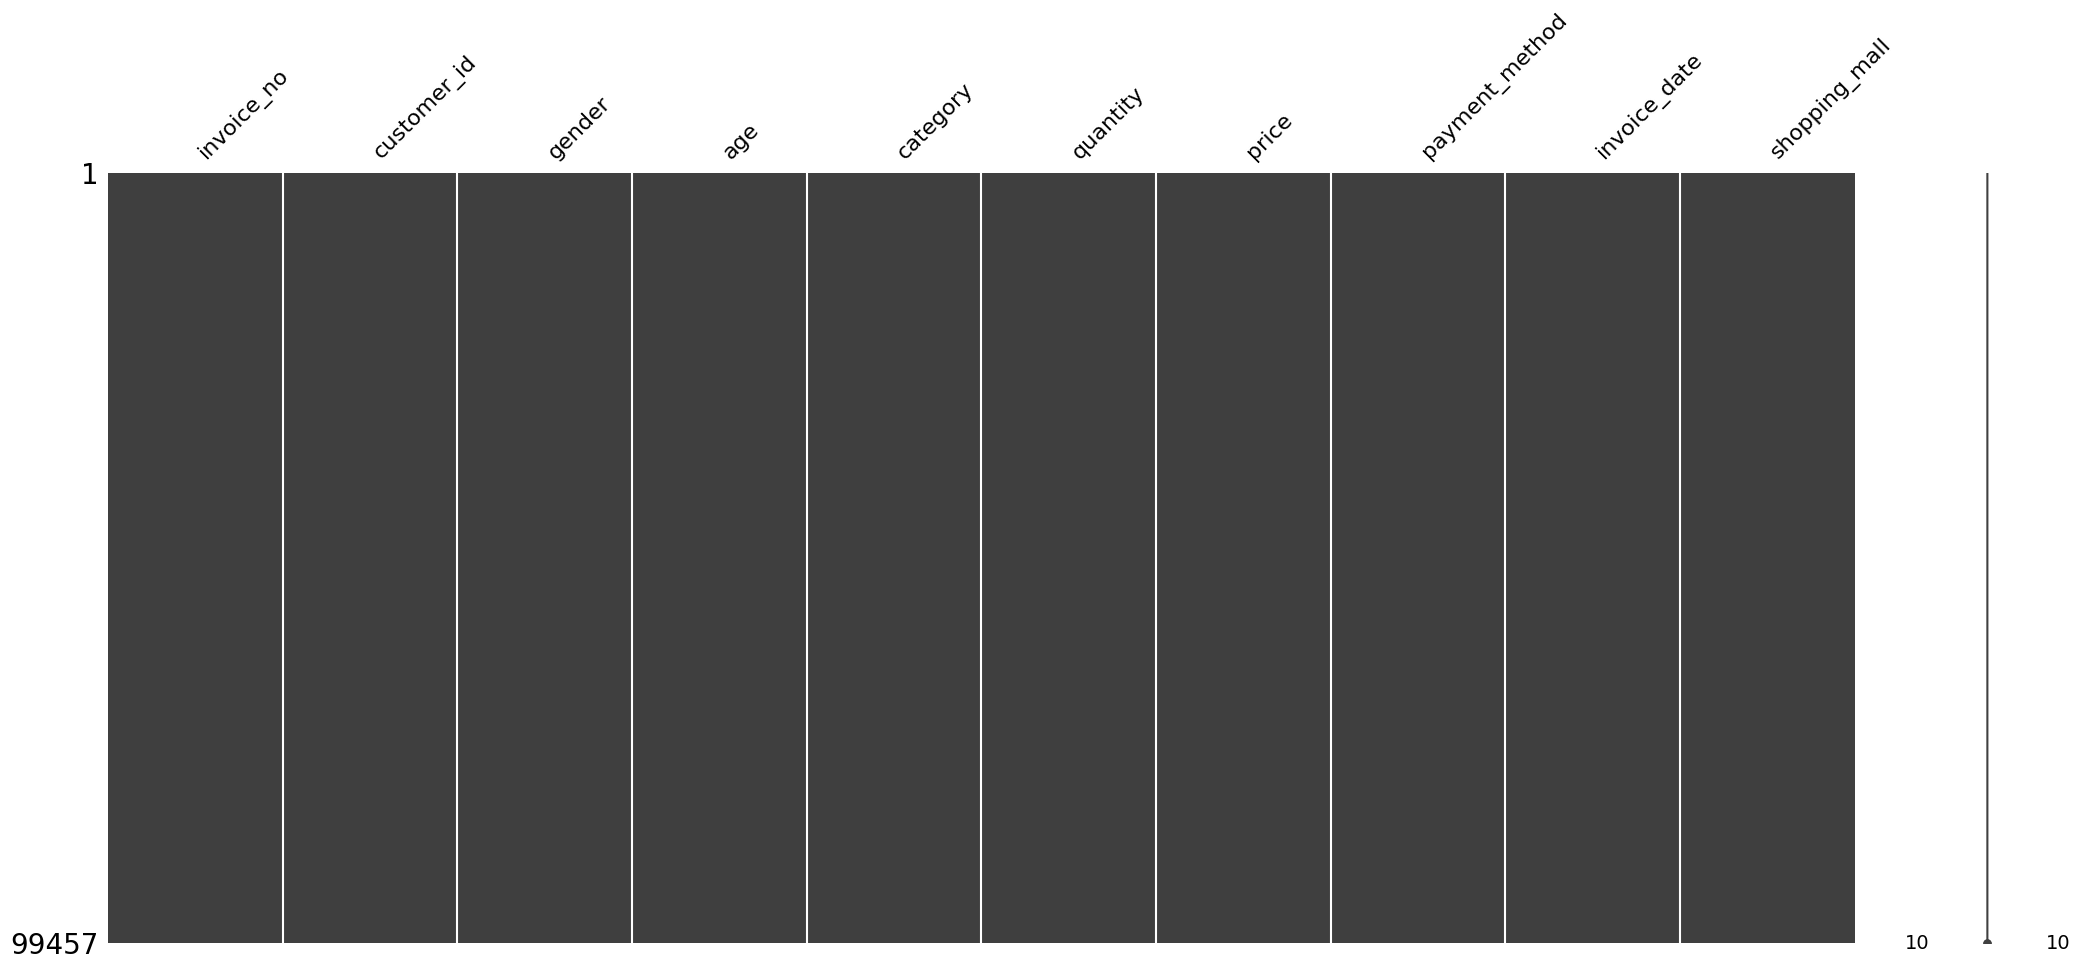

In [15]:
msno.matrix(df)

### Initial Data Exploration: Display Column Names
This cell simply outputs `df.columns`, which returns a list of all column names in the DataFrame. Knowing the exact column names is crucial for data manipulation, selection, and further analysis, preventing errors due to typos or incorrect casing.

In [17]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

### Data Visualization: Distribution Plots
This cell creates three separate distribution plots using `seaborn.distplot` for 'age', 'quantity', and 'price'. Distribution plots (also known as histograms or kernel density estimates) are vital for understanding the underlying distribution of individual numerical features. They help identify common patterns such as normal distribution, skewness, modality, and the presence of outliers. *Note: `distplot` is deprecated in newer Seaborn versions; `sns.histplot` or `sns.displot` are recommended alternatives.*

/tmp/ipykernel_372/1094085411.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


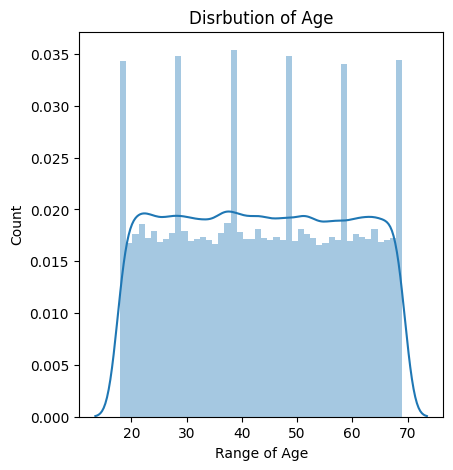

/tmp/ipykernel_372/1094085411.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['quantity'])


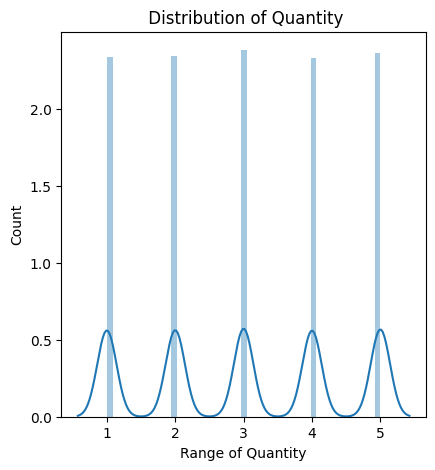

/tmp/ipykernel_372/1094085411.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


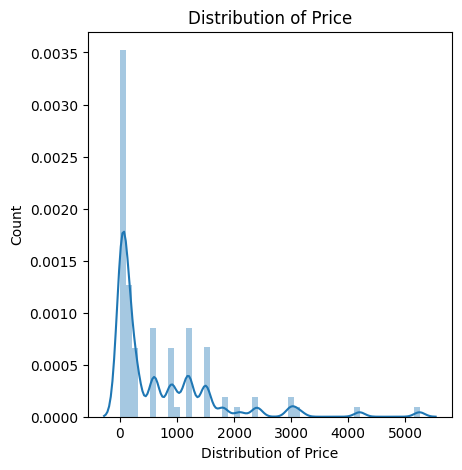

In [19]:
plt.figure(figsize = (16,5))

plt.subplot(1, 3, 1)
sns.distplot(df['age'])
plt.title("Disrbution of Age")
plt.xlabel("Range of Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize = (16,5))
plt.subplot(1, 3,2)
sns.distplot(df['quantity'])
plt.title(" Distribution of Quantity")
plt.xlabel("Range of Quantity")
plt.ylabel("Count")
plt.show()

plt.figure(figsize = (16,5))
plt.subplot(1, 3, 3)
sns.distplot(df['price'])
plt.title("Distribution of Price")
plt.xlabel("Distribution of Price")
plt.ylabel("Count")
plt.show()

### Data Visualization: Gender Distribution
This cell visualizes the distribution of genders in the dataset using a pie chart. First, `df.groupby('gender').size()` calculates the count of each gender. Then, `df.plot(kind='pie', ...)` generates the pie chart, showing the proportion of 'Female' and 'Male' customers. Pie charts are effective for representing parts of a whole and quickly understanding categorical proportions.

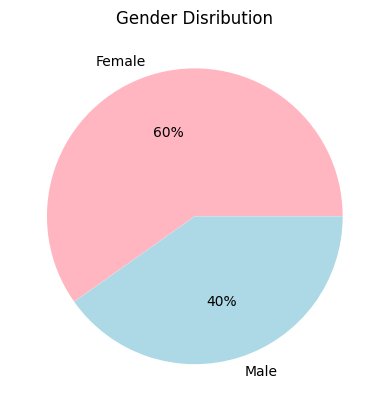

In [21]:
df = df.groupby('gender').size()

df.plot(kind='pie', subplots = True,
       colors = ['lightpink', 'lightblue'],
       explode = [0, 0.001],
       labels = ['Female', 'Male'],
       autopct = '%.f%%' )
plt.title("Gender Disribution")
plt.ylabel("")
plt.show()

### Setup: Install Dabl
This cell uses `!pip install dabl` to install the `dabl` (Data Analysis Baseline) library. `dabl` is a Python library designed for automated exploratory data analysis, simplifying the process of generating common plots and statistical summaries with minimal code, making EDA faster and more efficient.

In [25]:
!pip install dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 5.3 MB/s eta 0:00:00


### Setup: Import Dabl
After installing, this cell imports the `dabl` library into the current Python environment. This makes all functions and classes provided by `dabl` available for use in the subsequent cells of the notebook.

In [26]:
import dabl

### Data Exploration: Dabl Plot
This cell utilizes `dabl.plot(df, target_col = 'age')` to perform an automated exploratory data analysis, specifically focusing on how other features relate to 'age'. `dabl.plot` automatically generates various types of plots (e.g., scatter plots, box plots, histograms) based on the data types and relationships, providing a comprehensive overview of the dataset with respect to the specified target variable.

/usr/local/lib/python3.12/dist-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
/usr/local/lib/python3.12/dist-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
/usr/local/lib/python3.12/dist-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
/usr/local/lib/python3.12/dist-packages/dabl/preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling 

Target looks like classification
Not plotting anything for 50 classes or more.Current visualizations are quite useless for this many classes. Try slicing the data.


[<Axes: title={'center': 'Target distribution'}, xlabel='count', ylabel='age'>,
 [array([[<Axes: xlabel='price', ylabel='price'>]], dtype=object)],
 array([[<Axes: title={'center': 'invoice_date'}, xlabel='count', ylabel='invoice_date'>,
         <Axes: title={'center': 'shopping_mall'}, xlabel='count', ylabel='shopping_mall'>,
         <Axes: title={'center': 'category'}, xlabel='count', ylabel='category'>],
        [<Axes: title={'center': 'quantity'}, xlabel='count', ylabel='quantity'>,
         <Axes: title={'center': 'payment_method'}, xlabel='count', ylabel='payment_method'>,
         <Axes: title={'center': 'gender'}, xlabel='count', ylabel='gender'>]],
       dtype=object)]

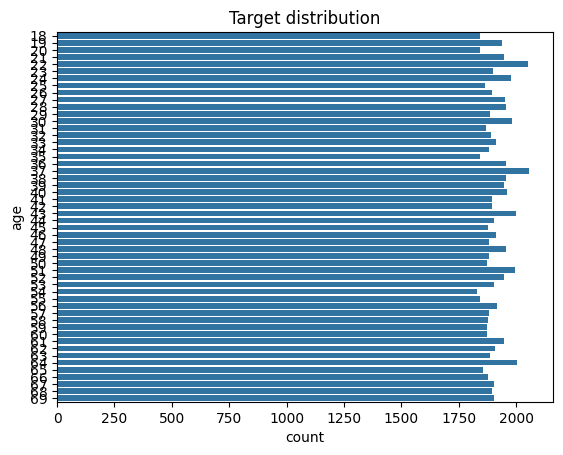

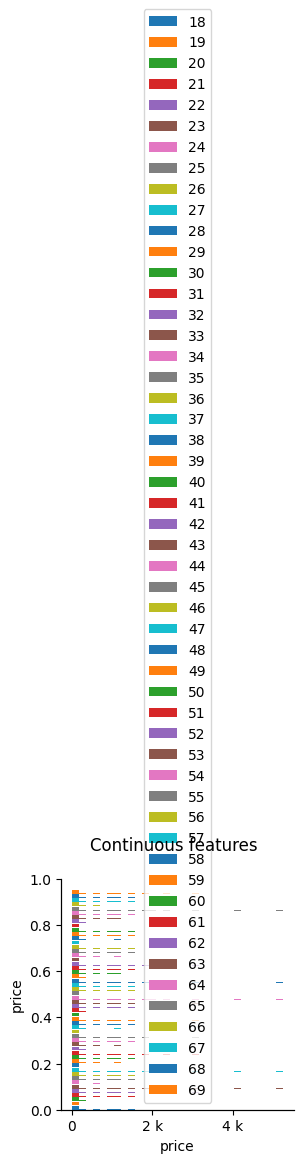

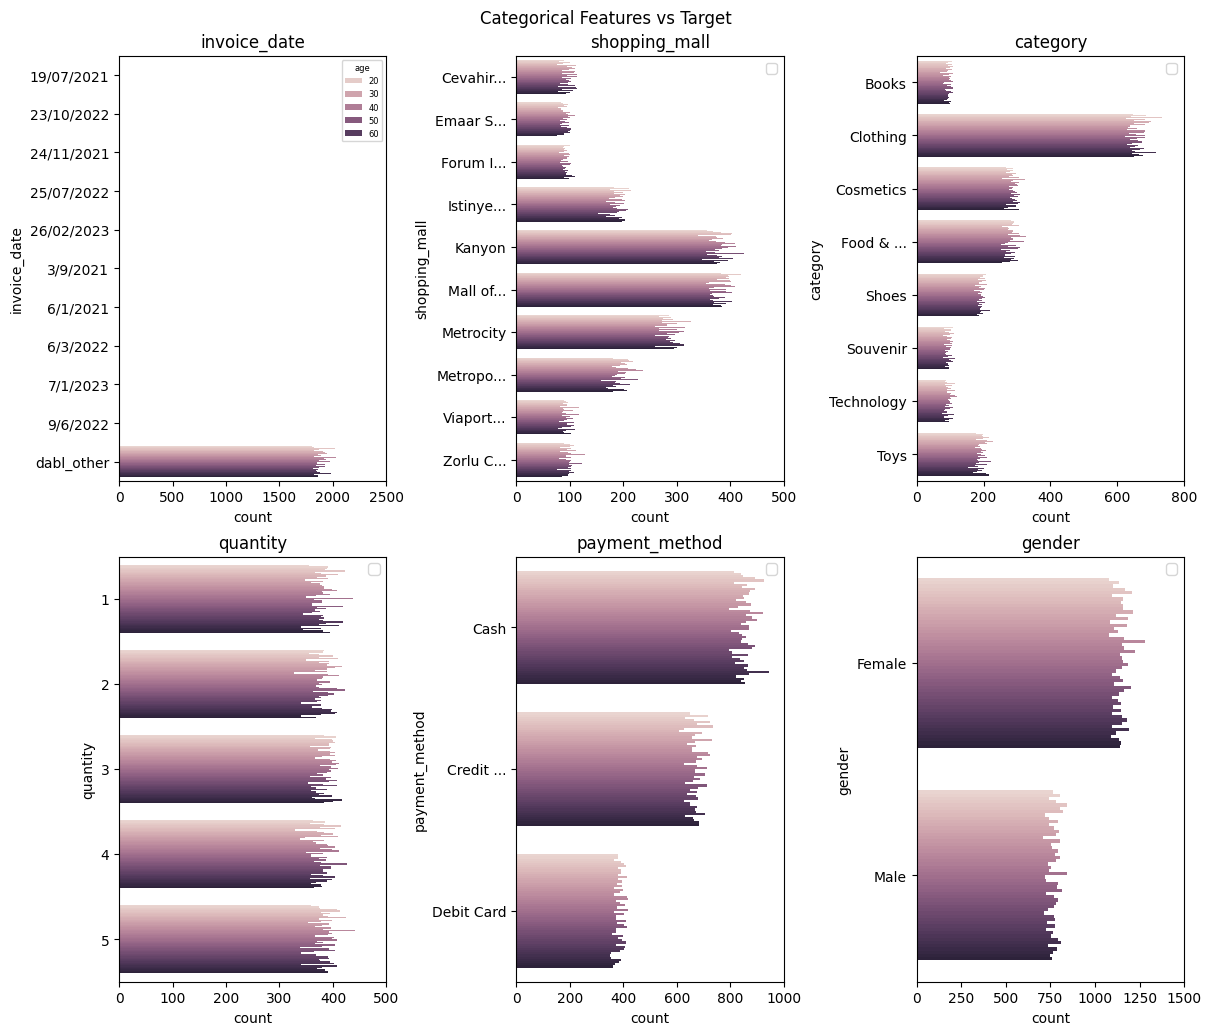

In [29]:
df = pd.read_csv('/content/drive/My Drive/ML LAB/TYAssignments/customer_shopping_data.csv')
dabl.plot(df, target_col = 'age')

### Data Visualization: Correlation Heatmap
This cell generates a heatmap of the correlation matrix for all numerical features in the DataFrame. `df.select_dtypes(include=np.number)` first filters for only numerical columns, and `.corr()` calculates the pairwise correlation between them. `sns.heatmap()` then visualizes these correlations, where color intensity and annotation (`annot=True`) indicate the strength and direction of linear relationships between variables (e.g., positive, negative, or no correlation). This helps in understanding feature interdependencies.

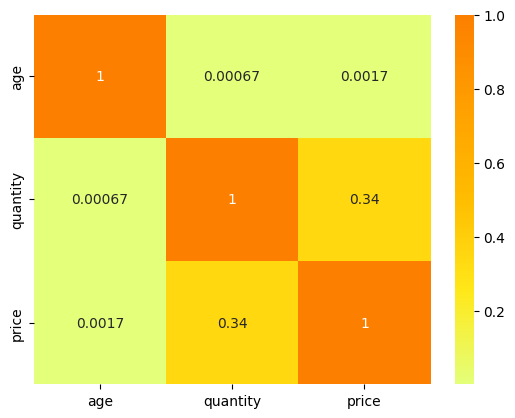

In [32]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap = 'Wistia', annot = True)
plt.show()

### Data Visualization: Age vs Quantity by Gender
This cell creates a scatter plot to visualize the relationship between 'age' and 'quantity', with points colored based on 'gender'. By iterating through each gender and plotting points separately, we can observe if the relationship between age and quantity differs for male and female customers. This type of visualization helps identify subgroups and potential patterns within the data.

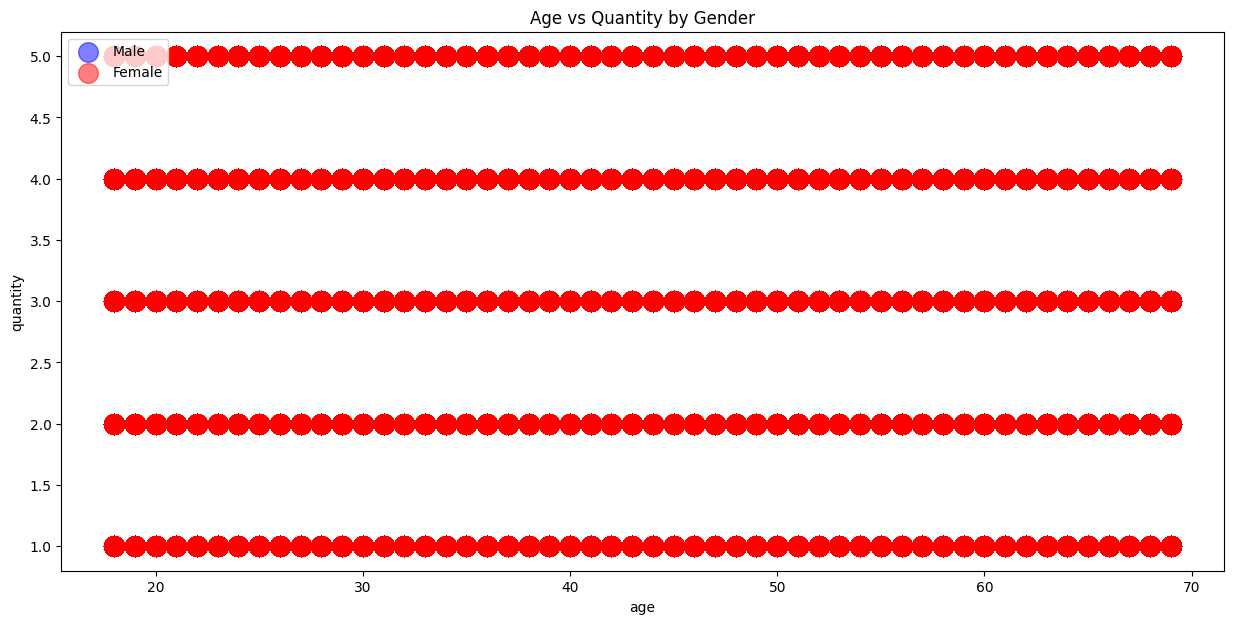

In [48]:
plt.figure(figsize = (15, 7))
colors = {'Male': 'blue', 'Female': 'red'} # Define specific colors for clarity
for gender_val in ['Male', 'Female']:
    subset_df = df[df['gender'] == gender_val]
    plt.scatter(x = subset_df['age'], y = subset_df['quantity'],
               s = 200, alpha = 0.5,
               color = colors[gender_val], # Use the specified color
               label = gender_val)
plt.xlabel("age")
plt.ylabel("quantity")
plt.title("Age vs Quantity by Gender") # Updated title for clarity
plt.legend()
plt.show()

### Data Visualization: Age vs Price by Gender
Similar to the previous plot, this cell generates another scatter plot, but this time it examines the relationship between 'age' and 'price', again differentiated by 'gender'. This allows for visual inspection of whether there are distinct purchasing behaviors (in terms of price) across different age groups and genders, which could be valuable for customer segmentation.

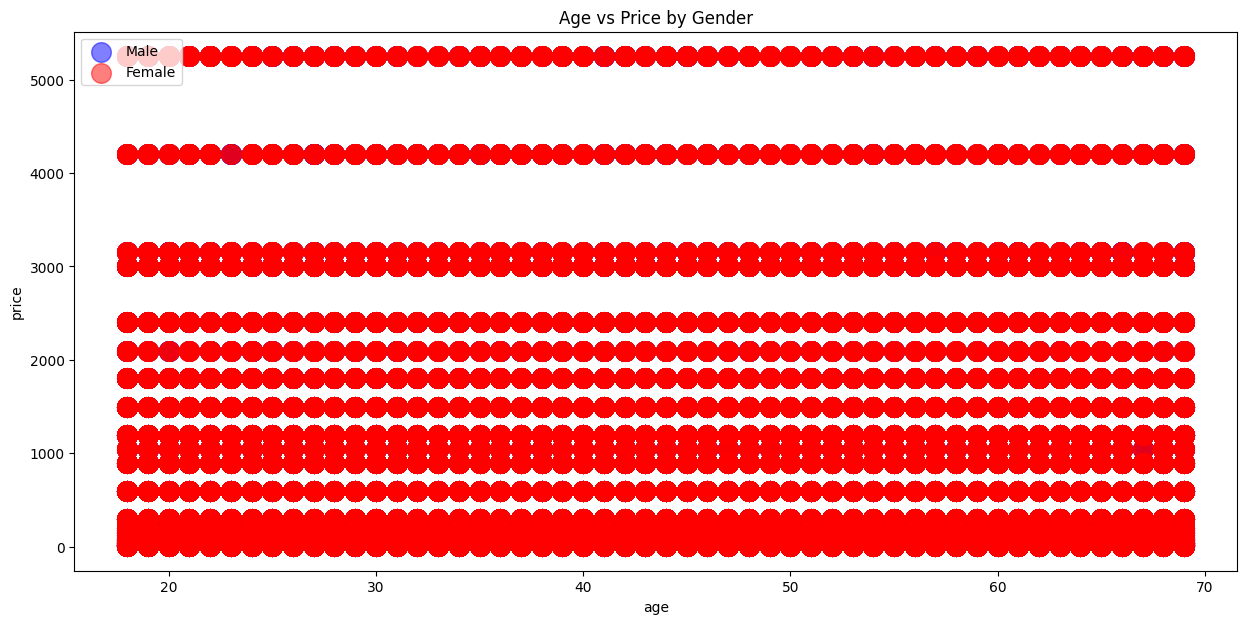

In [49]:
plt.figure(figsize = (15, 7))
colors = {'Male': 'blue', 'Female': 'red'} # Define specific colors for clarity
for gender_val in ['Male', 'Female']:
    subset_df = df[df['gender'] == gender_val]
    plt.scatter(x = subset_df['age'], y = subset_df['price'],
               s = 200, alpha = 0.5,
               color = colors[gender_val], # Use the specified color
               label = gender_val)
plt.xlabel("age")
plt.ylabel("price")
plt.title("Age vs Price by Gender") # Updated title for clarity
plt.legend()
plt.show()

### K-Means Clustering: Initial Data Selection
This cell begins the K-Means clustering process by selecting the features that will be used for clustering. Initially, it attempts to select 'age' and 'category' (index 3 and 4) using `df.iloc[:, [3,4]].values`. However, for K-Means, features should be numerical. This selection is later corrected to use only numerical features, but this cell represents the initial intent to prepare data for clustering.

In [38]:
x = df.iloc[:, [3,4]].values

### K-Means Clustering: Display Selected Data
This cell simply outputs the content of the `x` variable, which holds the features selected for clustering. It serves as a verification step to ensure that the correct data has been extracted and is in the expected format (e.g., a NumPy array) before proceeding with the clustering algorithm.

In [39]:
x

array([[28, 'Clothing'],
       [21, 'Shoes'],
       [20, 'Clothing'],
       ...,
       [63, 'Food & Beverage'],
       [56, 'Technology'],
       [36, 'Souvenir']], dtype=object)

### K-Means Clustering: Import KMeans
Before applying the K-Means algorithm, this cell imports the `KMeans` class from the `sklearn.cluster` module of the scikit-learn library. This import makes the K-Means algorithm available for use in the notebook, allowing for the creation and training of clustering models.

In [40]:
from sklearn.cluster import KMeans

### K-Means Clustering: Elbow Method Calculation
This cell prepares the data for K-Means by explicitly selecting the numerical features ('age', 'quantity', 'price') into the `x` variable. It then implements the Elbow method to find the optimal number of clusters (`k`). The loop iterates from 1 to 10 clusters, fits a KMeans model for each `k`, and records the `inertia_` (sum of squared distances of samples to their closest cluster center). The goal is to find the 'elbow point' in the resulting plot where the decrease in inertia slows down significantly.

In [42]:
x = df[['age', 'quantity', 'price']].values
k = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 0)
    kmeans.fit(x)
    k.append(kmeans.inertia_)

### K-Means Clustering: Elbow Method Plot
This cell plots the `inertia_` values (calculated in the previous step) against the corresponding number of clusters (`range(1, 11)`). This visualization is central to the Elbow method. The 'elbow' in the plot, where the rate of decrease in inertia sharply changes, is typically chosen as the optimal number of clusters, as adding more clusters beyond this point provides diminishing returns in terms of reducing within-cluster sum of squares.

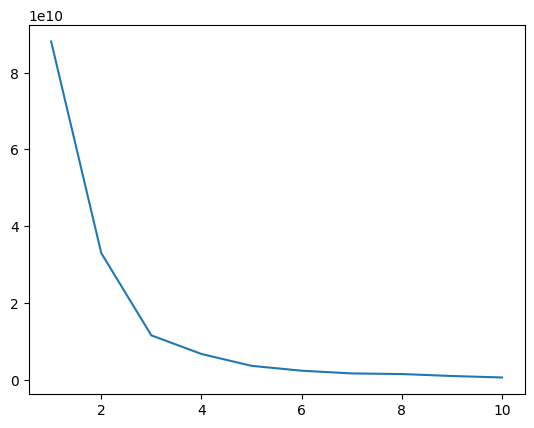

In [44]:
plt.plot(range(1, 11), k)
plt.show()

### K-Means Clustering: Model Training
This cell initializes and trains the K-Means clustering model. Based on the Elbow method's visual indication, `n_clusters` is set to 5. `init='k-means++'` is used for smart initialization of centroids to speed up convergence, and `random_state=0` ensures reproducibility of the results. Finally, `model.fit_predict(x)` trains the model on the data `x` and assigns each data point to its respective cluster, storing these assignments in `y_kemsn`.

In [45]:
model = KMeans(n_clusters = 5, init = 'k-means++', random_state = 0)
y_kemsn = model.fit_predict(x)

### K-Means Clustering: Visualizing the Clusters
This cell generates a scatter plot to visually represent the 5 clusters discovered by the K-Means algorithm. It plots 'age' (first feature, index 0) against 'price' (third feature, index 2) from the `x` data. Each cluster (`y_kemsn == N`) is assigned a distinct color (red, blue, green, cyan, magenta) to differentiate them. The cluster centroids, which are the centers of these clusters, are also plotted as larger yellow points, providing a clear understanding of the cluster separation and location.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


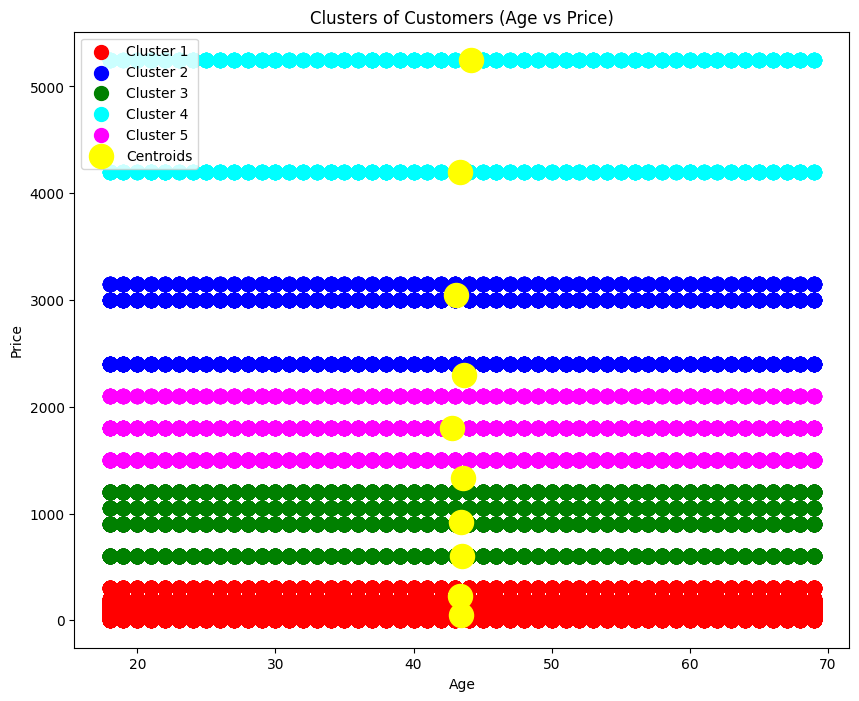

In [46]:
plt.figure(figsize = (10, 8))
plt.scatter(x[y_kemsn == 0, 0], x[y_kemsn == 0, 2], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(x[y_kemsn == 1, 0], x[y_kemsn == 1, 2], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(x[y_kemsn == 2, 0], x[y_kemsn == 2, 2], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(x[y_kemsn == 3, 0], x[y_kemsn == 3, 2], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(x[y_kemsn == 4, 0], x[y_kemsn == 4, 2], s = 100, c = 'magenta', label = 'Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of Customers (Age vs Price)')
plt.xlabel('Age')
plt.ylabel('Price')
plt.legend()
plt.show()

### K-Means Clustering: Evaluating Clustering with Silhouette Score
This cell calculates the Silhouette Score, a popular metric for evaluating the quality of clusters. The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to 1: a score close to 1 indicates that the object is well-matched to its own cluster and poorly matched to neighboring clusters; a score around 0 indicates overlapping clusters; and a score close to -1 suggests that objects might have been assigned to the wrong cluster. A score of `0.725` indicates relatively well-defined and separated clusters.

In [47]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(x, y_kemsn)
print(f"The average Silhouette Score for the 5 clusters is: {silhouette_avg:.3f}")

The average Silhouette Score for the 5 clusters is: 0.725


In [50]:
df.to_pickle('/content/drive/My Drive/ML LAB/TYAssignments/customer_shopping_data.pkl')
print("DataFrame saved as 'customer_shopping_data.pkl' in Google Drive.")

DataFrame saved as 'customer_shopping_data.pkl' in Google Drive.
